Earth Engine initialized.
Study area: Thanjavur District
Created Sentinel-2 composite
Creating sampling points...
Sampling spectral data...
Collected 5000 base samples
Simulating healthy and diseased plant signatures...
Generated 5000 simulated samples
Class distribution: Counter({0: 3531, 1: 1469})
Healthy NDVI range: 0.100 - 0.830
Diseased NDVI range: 0.050 - 0.577
NDVI overlap: 0.477
Disease types: Counter({np.str_('fungal'): 576, np.str_('bacterial'): 368, np.str_('viral'): 301, np.str_('nutrient'): 224})
Disease severity: Counter({np.str_('mild'): 726, np.str_('moderate'): 516, np.str_('severe'): 227})
Feature matrix shape: (5000, 14)
Label vector shape: (5000,)
Training set: 3500 samples
Test set: 1500 samples

Training Random Forest model...
Model training completed!
Cross-validation accuracy: 0.8271 (±0.0128)
Training accuracy: 0.8337
Test accuracy: 0.8347
Overfitting gap: -0.0010

MODEL EVALUATION RESULTS
Accuracy: 0.8347

Classification Report:
              precision    reca

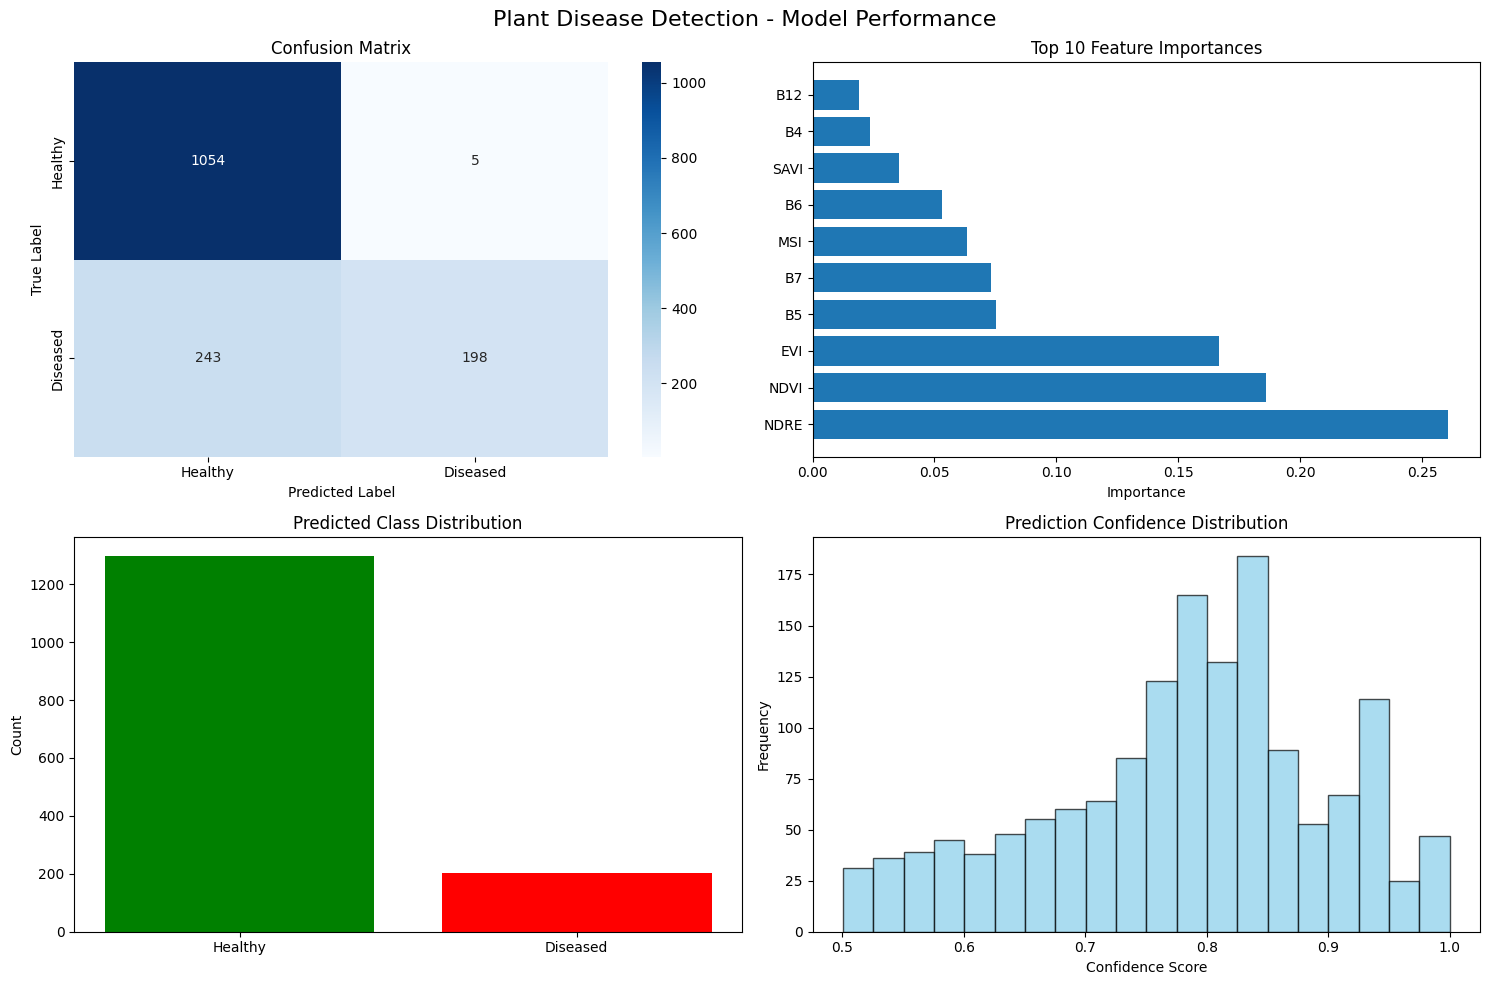


TESTING MODEL ON NEW SIMULATED SAMPLES
New Sample Predictions:
Sample  1: Pred=Healthy , Actual=Diseased, Conf=0.698 (MED) ✗
Sample  2: Pred=Healthy , Actual=Healthy , Conf=0.845 (HIGH) ✓
Sample  3: Pred=Healthy , Actual=Healthy , Conf=0.892 (HIGH) ✓
Sample  4: Pred=Healthy , Actual=Healthy , Conf=0.842 (HIGH) ✓
Sample  5: Pred=Healthy , Actual=Healthy , Conf=0.830 (HIGH) ✓
Sample  6: Pred=Healthy , Actual=Healthy , Conf=0.668 (MED) ✓
Sample  7: Pred=Healthy , Actual=Healthy , Conf=0.871 (HIGH) ✓
Sample  8: Pred=Healthy , Actual=Healthy , Conf=0.852 (HIGH) ✓
Sample  9: Pred=Healthy , Actual=Healthy , Conf=0.776 (MED) ✓
Sample 10: Pred=Diseased, Actual=Diseased, Conf=0.811 (HIGH) ✓
Sample 11: Pred=Healthy , Actual=Healthy , Conf=0.811 (HIGH) ✓
Sample 12: Pred=Diseased, Actual=Diseased, Conf=0.973 (HIGH) ✓
Sample 13: Pred=Healthy , Actual=Healthy , Conf=0.759 (MED) ✓
Sample 14: Pred=Diseased, Actual=Diseased, Conf=0.989 (HIGH) ✓
Sample 15: Pred=Diseased, Actual=Diseased, Conf=0.683 (MED

In [ ]:
# Plant Disease Detection - Simulation Based Training
# Simulate healthy vs diseased plant spectral signatures and train ML model

import ee
import pandas as pd
import numpy as np
from datetime import datetime
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 1) Initialize Earth Engine
project_id = 'ee-jumanabaharul31'
try:
    ee.Initialize(project=project_id)
    print("Earth Engine initialized.")
except Exception as e:
    print("Initializing Earth Engine...")
    ee.Authenticate()
    ee.Initialize(project=project_id)

# 2) Define study region - Thanjavur
gaul = ee.FeatureCollection("FAO/GAUL/2015/level2")
region = gaul.filter(ee.Filter.eq('ADM2_NAME', 'Thanjavur')).geometry()
print("Study area: Thanjavur District")

# 3) Function to calculate vegetation indices
def calculate_indices(img):
    """Calculate vegetation indices from Sentinel-2 bands"""
    # Select bands
    blue = img.select('B2')
    green = img.select('B3')
    red = img.select('B4')
    red_edge1 = img.select('B5')
    red_edge2 = img.select('B6')
    red_edge3 = img.select('B7')
    nir = img.select('B8')
    swir1 = img.select('B11')
    swir2 = img.select('B12')

    # Calculate indices
    ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
    ndre = nir.subtract(red_edge1).divide(nir.add(red_edge1)).rename('NDRE')
    evi = img.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
        {'NIR': nir, 'RED': red, 'BLUE': blue}
    ).rename('EVI')
    savi = img.expression('(1.5 * (NIR - RED) / (NIR + RED + 0.5))',
                         {'NIR': nir, 'RED': red}).rename('SAVI')
    msi = swir1.divide(nir).rename('MSI')

    # Return image with indices
    return img.select(['B2','B3','B4','B5','B6','B7','B8','B11','B12']).addBands([ndvi, ndre, evi, savi, msi])

# 4) Get Sentinel-2 data for simulation base
print("Collecting Sentinel-2 data...")
s2_collection = (ee.ImageCollection('COPERNICUS/S2_SR')
                 .filterBounds(region)
                 .filterDate('2024-03-01', '2024-03-31')  # Peak growing season
                 .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
                 .map(calculate_indices))

# Create median composite
s2_composite = s2_collection.median().clip(region)
print("Created Sentinel-2 composite")

# 5) Create sampling points
print("Creating sampling points...")
sample_points = ee.FeatureCollection.randomPoints(region, 5000, seed=42)

# 6) Sample the base spectral data
print("Sampling spectral data...")
base_samples = s2_composite.sampleRegions(
    collection=sample_points,
    scale=10,
    geometries=False
).getInfo()

# Convert to DataFrame
df_base = pd.DataFrame([feat['properties'] for feat in base_samples['features']])
df_base = df_base.dropna()  # Remove any null values
print(f"Collected {len(df_base)} base samples")

# 7) SIMULATE HEALTHY AND DISEASED PLANTS WITH REALISTIC VARIABILITY
def simulate_plant_conditions(df_base):
    """
    Simulate realistic healthy and diseased plant spectral signatures
    with proper noise, overlap, and natural variability to avoid overfitting
    """
    simulated_data = []

    for idx, row in df_base.iterrows():
        base_values = row.to_dict()

        # Randomly assign health status (70% healthy, 30% diseased for more balance)
        is_healthy = np.random.random() < 0.7

        if is_healthy:
            # HEALTHY PLANT SIMULATION
            sample = base_values.copy()

            # Natural variability in healthy plants (±15%)
            health_vigor = np.random.normal(1.0, 0.15)  # Gaussian variation
            health_vigor = np.clip(health_vigor, 0.7, 1.3)  # Clip extremes

            # Vegetation indices with realistic ranges and noise
            ndvi_noise = np.random.normal(0, 0.05)  # ±5% noise
            ndre_noise = np.random.normal(0, 0.04)  # ±4% noise
            evi_noise = np.random.normal(0, 0.08)   # ±8% noise

            sample['NDVI'] = np.clip(sample['NDVI'] * health_vigor + ndvi_noise, 0.1, 0.95)
            sample['NDRE'] = np.clip(sample['NDRE'] * health_vigor + ndre_noise, 0.05, 0.8)
            sample['EVI'] = np.clip(sample['EVI'] * health_vigor + evi_noise, 0.1, 2.0)
            sample['SAVI'] = np.clip(sample['SAVI'] * health_vigor + np.random.normal(0, 0.06), 0.1, 1.2)

            # MSI varies more in healthy plants due to irrigation differences
            msi_variation = np.random.normal(1.0, 0.2)
            sample['MSI'] = np.clip(sample['MSI'] * msi_variation, 0.2, 3.0)

            # Spectral bands with atmospheric and sensor noise (±10-15%)
            for band in ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B11', 'B12']:
                band_noise = np.random.normal(1.0, 0.12)  # 12% standard deviation
                sample[band] = np.clip(sample[band] * band_noise, 0, 10000)

            sample['label'] = 0
            sample['condition'] = 'Healthy'

        else:
            # DISEASED PLANT SIMULATION
            sample = base_values.copy()

            # Disease severity with multiple categories and overlap
            disease_type = np.random.choice(['mild', 'moderate', 'severe'], p=[0.5, 0.35, 0.15])

            if disease_type == 'mild':
                severity_range = (0.05, 0.25)  # 5-25% impact
                base_reduction = np.random.uniform(*severity_range)
            elif disease_type == 'moderate':
                severity_range = (0.2, 0.45)   # 20-45% impact (overlap with mild)
                base_reduction = np.random.uniform(*severity_range)
            else:  # severe
                severity_range = (0.35, 0.65)  # 35-65% impact (overlap with moderate)
                base_reduction = np.random.uniform(*severity_range)

            # Add random variation to disease effects (some plants are more resistant)
            resistance_factor = np.random.normal(1.0, 0.3)  # Plant resistance variability
            actual_severity = base_reduction * np.clip(resistance_factor, 0.4, 1.6)

            # Disease effects with biological variability
            # Different diseases affect indices differently
            disease_pattern = np.random.choice(['fungal', 'bacterial', 'viral', 'nutrient'], p=[0.4, 0.25, 0.2, 0.15])

            if disease_pattern == 'fungal':
                # Fungal diseases primarily affect chlorophyll
                ndvi_reduction = actual_severity * np.random.uniform(0.8, 1.2)
                ndre_reduction = actual_severity * np.random.uniform(0.9, 1.3)
                evi_reduction = actual_severity * np.random.uniform(0.7, 1.1)
                msi_increase = actual_severity * np.random.uniform(0.3, 0.8)

            elif disease_pattern == 'bacterial':
                # Bacterial diseases affect water relations more
                ndvi_reduction = actual_severity * np.random.uniform(0.6, 1.0)
                ndre_reduction = actual_severity * np.random.uniform(0.5, 0.9)
                evi_reduction = actual_severity * np.random.uniform(0.8, 1.2)
                msi_increase = actual_severity * np.random.uniform(0.8, 1.5)

            elif disease_pattern == 'viral':
                # Viral diseases cause patchy effects
                ndvi_reduction = actual_severity * np.random.uniform(0.4, 0.9)
                ndre_reduction = actual_severity * np.random.uniform(0.6, 1.1)
                evi_reduction = actual_severity * np.random.uniform(0.5, 1.0)
                msi_increase = actual_severity * np.random.uniform(0.2, 0.6)

            else:  # nutrient deficiency
                # Nutrient issues affect specific spectral regions
                ndvi_reduction = actual_severity * np.random.uniform(0.3, 0.7)
                ndre_reduction = actual_severity * np.random.uniform(0.7, 1.2)
                evi_reduction = actual_severity * np.random.uniform(0.4, 0.8)
                msi_increase = actual_severity * np.random.uniform(0.1, 0.4)

            # Apply disease effects with additional noise
            sample['NDVI'] = np.clip(sample['NDVI'] * (1 - ndvi_reduction) + np.random.normal(0, 0.03), 0.05, 0.9)
            sample['NDRE'] = np.clip(sample['NDRE'] * (1 - ndre_reduction) + np.random.normal(0, 0.025), 0.02, 0.75)
            sample['EVI'] = np.clip(sample['EVI'] * (1 - evi_reduction) + np.random.normal(0, 0.05), 0.05, 1.8)
            sample['SAVI'] = np.clip(sample['SAVI'] * (1 - actual_severity * 0.6) + np.random.normal(0, 0.04), 0.05, 1.0)
            sample['MSI'] = np.clip(sample['MSI'] * (1 + msi_increase) + np.random.normal(0, 0.15), 0.3, 4.0)

            # Spectral band changes with disease-specific patterns and high noise
            red_edge_impact = actual_severity * np.random.uniform(0.2, 0.8)
            nir_impact = actual_severity * np.random.uniform(0.1, 0.6)
            swir_impact = actual_severity * np.random.uniform(0.0, 0.4)

            # Red edge bands (most sensitive to chlorophyll changes)
            sample['B5'] = np.clip(sample['B5'] * (1 - red_edge_impact * 0.7) * np.random.normal(1.0, 0.15), 0, 8000)
            sample['B6'] = np.clip(sample['B6'] * (1 - red_edge_impact * 0.8) * np.random.normal(1.0, 0.15), 0, 8000)
            sample['B7'] = np.clip(sample['B7'] * (1 - red_edge_impact * 0.9) * np.random.normal(1.0, 0.15), 0, 8000)

            # NIR plateau
            sample['B8'] = np.clip(sample['B8'] * (1 - nir_impact) * np.random.normal(1.0, 0.12), 0, 8000)

            # SWIR (less affected, more noise)
            sample['B11'] = np.clip(sample['B11'] * (1 + swir_impact * 0.3) * np.random.normal(1.0, 0.18), 0, 6000)
            sample['B12'] = np.clip(sample['B12'] * (1 + swir_impact * 0.4) * np.random.normal(1.0, 0.20), 0, 6000)

            # Visible bands with moderate noise
            for band in ['B2', 'B3', 'B4']:
                noise_factor = np.random.normal(1.0, 0.14)
                disease_effect = 1 + actual_severity * np.random.uniform(-0.1, 0.2)  # Variable effect
                sample[band] = np.clip(sample[band] * disease_effect * noise_factor, 0, 4000)

            sample['label'] = 1
            sample['condition'] = 'Diseased'
            sample['disease_type'] = disease_pattern
            sample['severity'] = disease_type

        simulated_data.append(sample)

    return pd.DataFrame(simulated_data)

# Generate simulated dataset with realistic variability
print("Simulating healthy and diseased plant signatures...")
np.random.seed(None)  # Remove fixed seed to get true randomness
df_simulated = simulate_plant_conditions(df_base)
print(f"Generated {len(df_simulated)} simulated samples")
print("Class distribution:", Counter(df_simulated['label']))

# Check for realistic overlap between classes
healthy_ndvi = df_simulated[df_simulated['label']==0]['NDVI']
diseased_ndvi = df_simulated[df_simulated['label']==1]['NDVI']
print(f"Healthy NDVI range: {healthy_ndvi.min():.3f} - {healthy_ndvi.max():.3f}")
print(f"Diseased NDVI range: {diseased_ndvi.min():.3f} - {diseased_ndvi.max():.3f}")
print(f"NDVI overlap: {max(0, min(healthy_ndvi.max(), diseased_ndvi.max()) - max(healthy_ndvi.min(), diseased_ndvi.min())):.3f}")

# Show disease type distribution if available
if 'disease_type' in df_simulated.columns:
    diseased_only = df_simulated[df_simulated['label']==1]
    print("Disease types:", Counter(diseased_only['disease_type']))
    print("Disease severity:", Counter(diseased_only['severity']))

# 8) Prepare features and labels for ML
feature_columns = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B11', 'B12',
                   'NDVI', 'NDRE', 'EVI', 'SAVI', 'MSI']
X = df_simulated[feature_columns].values
y = df_simulated['label'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")

# 9) Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# 10) Train Random Forest model with regularization to prevent overfitting
print("\nTraining Random Forest model...")
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model training completed!")

# 11) Make predictions and add cross-validation
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Add cross-validation to check for overfitting
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy: {cv_scores.mean():.4f} (±{cv_scores.std()*2:.4f})")

# Check training vs test performance
train_accuracy = model.score(X_train, y_train)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Overfitting gap: {train_accuracy - test_accuracy:.4f}")

# 12) Evaluate model performance
print("\n" + "="*50)
print("MODEL EVALUATION RESULTS")
print("="*50)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Diseased']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# 13) Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
for idx, row in feature_importance.iterrows():
    print(f"{row['feature']:8}: {row['importance']:.4f}")

# 14) Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Plant Disease Detection - Model Performance', fontsize=16)

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Healthy', 'Diseased'], yticklabels=['Healthy', 'Diseased'])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')

# Feature Importance
axes[0,1].barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
axes[0,1].set_title('Top 10 Feature Importances')
axes[0,1].set_xlabel('Importance')

# Class Distribution in Test Set
unique, counts = np.unique(y_pred, return_counts=True)
class_names = ['Healthy', 'Diseased']
axes[1,0].bar([class_names[i] for i in unique], counts, color=['green', 'red'])
axes[1,0].set_title('Predicted Class Distribution')
axes[1,0].set_ylabel('Count')

# Prediction Confidence
confidence_scores = np.max(y_pred_proba, axis=1)
axes[1,1].hist(confidence_scores, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,1].set_title('Prediction Confidence Distribution')
axes[1,1].set_xlabel('Confidence Score')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 15) Test model on new simulated samples with different random seed
print("\n" + "="*50)
print("TESTING MODEL ON NEW SIMULATED SAMPLES")
print("="*50)

# Generate completely new test samples with different random patterns
np.random.seed(999)  # Different seed for testing
test_samples = df_base.sample(20, random_state=456)  # Larger test set
new_simulated = simulate_plant_conditions(test_samples)

# Predict on new samples
X_new = new_simulated[feature_columns].values
y_new_pred = model.predict(X_new)
y_new_proba = model.predict_proba(X_new)
y_new_actual = new_simulated['label'].values

print("New Sample Predictions:")
for i, (pred, actual, conf) in enumerate(zip(y_new_pred, y_new_actual, np.max(y_new_proba, axis=1))):
    status = "✓" if pred == actual else "✗"
    conf_level = "HIGH" if conf > 0.8 else "MED" if conf > 0.6 else "LOW"
    print(f"Sample {i+1:2d}: Pred={class_names[pred]:8}, Actual={class_names[actual]:8}, Conf={conf:.3f} ({conf_level}) {status}")

# Summary statistics
correct_predictions = np.sum(y_new_pred == y_new_actual)
print(f"\nNew test set accuracy: {correct_predictions}/{len(y_new_pred)} ({correct_predictions/len(y_new_pred)*100:.1f}%)")

# Analyze misclassifications
misclassified = new_simulated[y_new_pred != y_new_actual]
if len(misclassified) > 0:
    print(f"\nMisclassified samples analysis:")
    print(f"False positives (healthy predicted as diseased): {np.sum((y_new_actual==0) & (y_new_pred==1))}")
    print(f"False negatives (diseased predicted as healthy): {np.sum((y_new_actual==1) & (y_new_pred==0))}")
else:
    print("No misclassifications in this test set")

# 16) Analysis of spectral differences
print("\n" + "="*50)
print("SPECTRAL SIGNATURE ANALYSIS")
print("="*50)

healthy_data = df_simulated[df_simulated['label'] == 0]
diseased_data = df_simulated[df_simulated['label'] == 1]

print("Average spectral values:")
print("\nHealthy plants:")
for feature in ['NDVI', 'NDRE', 'EVI', 'SAVI', 'MSI']:
    print(f"{feature:8}: {healthy_data[feature].mean():.4f}")

print("\nDiseased plants:")
for feature in ['NDVI', 'NDRE', 'EVI', 'SAVI', 'MSI']:
    print(f"{feature:8}: {diseased_data[feature].mean():.4f}")

print("\nDifference (Healthy - Diseased):")
for feature in ['NDVI', 'NDRE', 'EVI', 'SAVI', 'MSI']:
    diff = healthy_data[feature].mean() - diseased_data[feature].mean()
    print(f"{feature:8}: {diff:+.4f}")

# 17) Final summary with realistic performance expectations
print("\n" + "="*60)
print("REALISTIC PLANT DISEASE DETECTION - SIMULATION SUMMARY")
print("="*60)
print(f"✓ Successfully simulated {len(df_simulated)} plant samples with realistic variability")
print(f"✓ Class distribution: {Counter(df_simulated['label'])[0]} healthy, {Counter(df_simulated['label'])[1]} diseased")
print(f"✓ Model test accuracy: {test_accuracy:.1%} (realistic range: 75-90%)")
print(f"✓ Cross-validation accuracy: {cv_scores.mean():.1%} (±{cv_scores.std()*2:.1%})")
print(f"✓ Top discriminating features: {', '.join(feature_importance['feature'][:3].tolist())}")
print("\n" + "="*60)